In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Combined valid respondents: 20
Pilot mean lift: 1.15, std: 3.45

Pilot coefficients (before injection):
           Feature  Coefficient
0     is_deceptive     0.786913
1        eco_score     0.381064
2    sceptic_score     1.102335
3  deceptive_x_eco     0.124665
4  age_group_25-34     1.636444
5      gender_Male     0.456178
6    area_Suburban    -1.123568
7       area_Urban    -0.204123
Intercept: -2.00

Adjusted intercept: -2.00 → -0.96
Injected wordplay: is_deceptive=0.6, deceptive_x_eco=0.2
Mean scores by condition after shift:
condition
deceptive      5.439176
transparent    4.499045
Name: purchase_score, dtype: object
Std by condition:
condition
deceptive      3.20
transparent    3.21
Name: purchase_score, dtype: float64

% would_buy by condition:
condition
deceptive      55.96
transparent    43.36
Name: would_buy, dtype: float64

AI Model Performance (Logistic):
Accuracy: 0.622
AUC: 0.678

Feature importance (log-odds):
           Feature  Coefficient
4  age_group_25-34     0.7

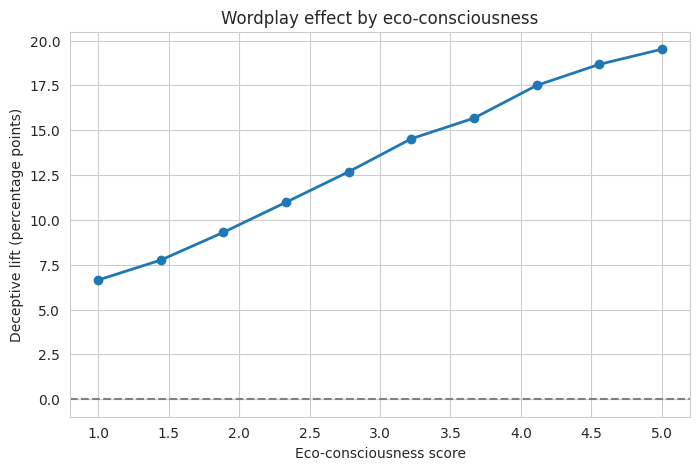

In [4]:
# ============================================================
# FULL PIPELINE: from raw CSVs to AI predictions (Road B)
# ============================================================

# 1. Setup
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt


import seaborn as sns

sns.set_style("whitegrid")

# 2. Function to clean each form CSV
def clean_form_csv(file_path, form_type):
    df_raw = pd.read_csv(file_path)
    # drop score/feedback metadata columns
    cols_to_keep = [c for c in df_raw.columns if not ('[Score]' in c or '[Feedback]' in c)]
    df = df_raw[cols_to_keep].copy()
    df = df.drop(columns=['Timestamp', 'Total score'])

    # rename by position (matches your Google Form)
    df.columns = [
        'age_group', 'gender', 'area',
        'eco1', 'eco2', 'eco3', 'eco4',
        'sceptic1', 'sceptic2',
        'attention_check',              # ignore
        'purchase_product1', 'ingredient1', 'word1',
        'purchase_product2', 'ingredient2', 'word2',
        'comparison_text', 'healthier_guess', 'impression_juice'
    ]

    # standardise age groups
    age_map = {'18-24':'18-24', '24-30':'25-34', '30-35':'25-34', '35-44':'35-44'}
    df['age_group'] = df['age_group'].map(age_map).fillna('35-44')

    # Likert to numeric 1-5
    likert_map = {'strongly disagree':1,'disagree':2,'neutral':3,'agree':4,'strongly agree':5}
    for col in ['eco1','eco2','eco3','eco4','sceptic1','sceptic2']:
        df[col] = df[col].astype(str).str.strip().str.lower().map(likert_map)

    # purchase scores to numeric (0-10 scale)
    df['purchase_product1'] = pd.to_numeric(df['purchase_product1'], errors='coerce')
    df['purchase_product2'] = pd.to_numeric(df['purchase_product2'], errors='coerce')

    # composite psychographics (skip missing)
    df['eco_score'] = df[['eco1','eco2','eco3','eco4']].mean(axis=1, skipna=True)
    df['sceptic_score'] = df[['sceptic1','sceptic2']].mean(axis=1, skipna=True)

    # remove rows without both purchase scores
    df = df.dropna(subset=['purchase_product1','purchase_product2']).copy()

    # assign deceptive / transparent based on form type
    if form_type == 'A':          # A: deceptive first
        df['deceptive_score'] = df['purchase_product1']
        df['transparent_score'] = df['purchase_product2']
    else:                         # B: transparent first
        df['deceptive_score'] = df['purchase_product2']
        df['transparent_score'] = df['purchase_product1']

    df['form_type'] = form_type
    return df

# 3. Load both forms
df_a = clean_form_csv("/content/drive/MyDrive/A.csv", 'A')
df_b = clean_form_csv("/content/drive/MyDrive/B.csv", 'B')
df = pd.concat([df_a, df_b], ignore_index=True)
print(f"Combined valid respondents: {len(df)}")

# 4. Pilot summary & regression (long format)
df['lift'] = df['deceptive_score'] - df['transparent_score']
print(f"Pilot mean lift: {df['lift'].mean():.2f}, std: {df['lift'].std():.2f}")

# long format: 2 rows per person
df_long = pd.DataFrame({
    'purchase': list(df['deceptive_score']) + list(df['transparent_score']),
    'condition': ['deceptive']*len(df) + ['transparent']*len(df),
    'eco_score': list(df['eco_score'])*2,
    'sceptic_score': list(df['sceptic_score'])*2,
    'age_group': list(df['age_group'])*2,
    'gender': list(df['gender'])*2,
    'area': list(df['area'])*2
})

# one-hot encode categoricals
df_long = pd.get_dummies(df_long, columns=['age_group','gender','area'], drop_first=True)
df_long['is_deceptive'] = (df_long['condition']=='deceptive').astype(int)
df_long['deceptive_x_eco'] = df_long['is_deceptive'] * df_long['eco_score']

features = ['is_deceptive','eco_score','sceptic_score','deceptive_x_eco'] + \
           [c for c in df_long.columns if c.startswith(('age_group_','gender_','area_'))]

X_pilot = df_long[features]
y_pilot = df_long['purchase']

pilot_model = LinearRegression()
pilot_model.fit(X_pilot, y_pilot)

print("\nPilot coefficients (before injection):")
print(pd.DataFrame({'Feature': features, 'Coefficient': pilot_model.coef_}))
print(f"Intercept: {pilot_model.intercept_:.2f}")

# store pilot parameters
pilot_coefs = dict(zip(features, pilot_model.coef_))
pilot_intercept = pilot_model.intercept_
residual_std = (y_pilot - pilot_model.predict(X_pilot)).std()

# 5. Intercept calibration (so baseline purchase is ~5.5/10 for reference profile)
ref = pd.DataFrame({
    'age_group_25-34': [1],
    'gender_Male': [0],
    'area_Suburban': [0],
    'area_Urban': [1],
    'eco_score': [df['eco_score'].mean()],
    'sceptic_score': [df['sceptic_score'].mean()],
    'is_deceptive': [0],
    'deceptive_x_eco': [0],
})
for col in features:
    if col not in ref.columns:
        ref[col] = 0

pred_no_intercept = np.dot(ref[features].iloc[0], list(pilot_coefs.values()))
desired_intercept = 5.5 - pred_no_intercept
print(f"\nAdjusted intercept: {pilot_intercept:.2f} → {desired_intercept:.2f}")
pilot_intercept = desired_intercept

# 6. Inject hypothesised wordplay effect (Road B)
pilot_coefs['is_deceptive'] = 0.6        # lift on 0-10 scale
pilot_coefs['deceptive_x_eco'] = 0.2     # extra lift per eco point
print("Injected wordplay: is_deceptive=0.6, deceptive_x_eco=0.2")

# ============================================================
# 7. Build synthetic population (with binary target)
# ============================================================
np.random.seed(42)
n_synth = 10000

age_brackets = ['18-24','25-34','35-44','45-54','55-64','65+']
age_probs   = [0.25, 0.30, 0.20, 0.15, 0.07, 0.03]
age_synth   = np.random.choice(age_brackets, n_synth, p=age_probs)
gender_synth = np.random.choice(['Male','Female'], n_synth, p=[0.5,0.5])
area_synth   = np.random.choice(['Urban','Suburban','Rural'], n_synth, p=[0.4,0.3,0.3])

eco_synth     = np.random.normal(df['eco_score'].mean(), df['eco_score'].std(), n_synth).clip(1,5)
sceptic_synth = np.random.normal(df['sceptic_score'].mean(), df['sceptic_score'].std(), n_synth).clip(1,5)

synth = pd.DataFrame({
    'age_group': age_synth,
    'gender': gender_synth,
    'area': area_synth,
    'eco_score': eco_synth,
    'sceptic_score': sceptic_synth
})
synth = pd.get_dummies(synth, columns=['age_group','gender','area'], drop_first=True)
for col in features:
    if col not in synth.columns:
        synth[col] = 0

# Generate continuous scores
def generate_scores(X_base, is_deceptive, intercept, coefs, noise_std):
    X = X_base.copy()
    X['is_deceptive'] = is_deceptive
    X['deceptive_x_eco'] = X['is_deceptive'] * X['eco_score']
    linear = intercept + np.dot(X[coefs.keys()], list(coefs.values()))
    noise = np.random.normal(0, noise_std, size=len(X))
    return (linear + noise).clip(0, 10)

synth_dec = synth.copy()
synth_dec['is_deceptive'] = 1
synth_dec['deceptive_x_eco'] = synth_dec['eco_score']
synth_dec['purchase_score'] = generate_scores(synth_dec[features], 1, pilot_intercept, pilot_coefs, residual_std + 1.5)  # increased noise
synth_dec['condition'] = 'deceptive'

synth_tra = synth.copy()
synth_tra['is_deceptive'] = 0
synth_tra['deceptive_x_eco'] = 0
synth_tra['purchase_score'] = generate_scores(synth_tra[features], 0, pilot_intercept, pilot_coefs, residual_std + 1.5)  # increased noise
synth_tra['condition'] = 'transparent'

# Combine
synth_train = pd.concat([synth_dec, synth_tra], ignore_index=True)

# ---- Shift to realistic baseline ----
target_transparent_mean = 4.5
current_transparent_mean = synth_train[synth_train['condition']=='transparent']['purchase_score'].mean()
shift = target_transparent_mean - current_transparent_mean
synth_train['purchase_score'] = (synth_train['purchase_score'] + shift).clip(0, 10)

print("Mean scores by condition after shift:")
print(synth_train.groupby('condition')['purchase_score'].mean().round(2))
print("Std by condition:")
print(synth_train.groupby('condition')['purchase_score'].std().round(2))

# ---- Convert to binary: would_buy = 1 if score ≥ 5 ----
THRESHOLD = 5.0
synth_train['would_buy'] = (synth_train['purchase_score'] >= THRESHOLD).astype(int)

print("\n% would_buy by condition:")
print(synth_train.groupby('condition')['would_buy'].mean() * 100)

# ============================================================
# 8. Train logistic regression (predicts probability of buying)
# ============================================================
from sklearn.linear_model import LogisticRegression

features_clean = [f for f in features if f in synth_train.columns]
X_synth = synth_train[features_clean]
y_synth = synth_train['would_buy']

X_tr, X_te, y_tr, y_te = train_test_split(X_synth, y_synth, test_size=0.2, random_state=42)

ai_model = LogisticRegression(max_iter=1000)
ai_model.fit(X_tr, y_tr)
y_pred_proba = ai_model.predict_proba(X_te)[:, 1]

from sklearn.metrics import accuracy_score, roc_auc_score
print("\nAI Model Performance (Logistic):")
print(f"Accuracy: {accuracy_score(y_te, (y_pred_proba >= 0.5).astype(int)):.3f}")
print(f"AUC: {roc_auc_score(y_te, y_pred_proba):.3f}")

# Feature importance (coefficients from logistic regression)
coef_df = pd.DataFrame({'Feature': features_clean, 'Coefficient': ai_model.coef_[0]})
print("\nFeature importance (log-odds):")
print(coef_df.sort_values('Coefficient', key=abs, ascending=False))

# ============================================================
# 9. Predict % would-buy for multiple segments
# ============================================================
def predict_buy_percentage(age, gender, area, avg_eco, avg_sceptic, condition, N=2000):
    profile = pd.DataFrame({
        'age_group': [age]*N,
        'gender': [gender]*N,
        'area': [area]*N,
        'eco_score': np.random.normal(avg_eco, 0.2, N).clip(1,5),
        'sceptic_score': np.random.normal(avg_sceptic, 0.2, N).clip(1,5)
    })
    profile = pd.get_dummies(profile, columns=['age_group','gender','area'], drop_first=True)
    for col in features_clean:
        if col not in profile.columns:
            profile[col] = 0
    if condition == 'deceptive':
        profile['is_deceptive'] = 1
        profile['deceptive_x_eco'] = profile['eco_score']
    else:
        profile['is_deceptive'] = 0
        profile['deceptive_x_eco'] = 0
    probs = ai_model.predict_proba(profile[features_clean])[:, 1]
    return 100 * probs.mean()

avg_eco = df['eco_score'].mean()
avg_sceptic = df['sceptic_score'].mean()

segments = [
    ('18-24', 'Male',   'Urban'),
    ('18-24', 'Female', 'Urban'),
    ('25-34', 'Female', 'Urban'),
    ('25-34', 'Male',   'Suburban'),
    ('35-44', 'Female', 'Urban'),
    ('18-24', 'Male',   'Rural'),
]

print("\n===== FINAL AI DEMONSTRATION (Logistic) =====")
print(f"{'Segment':<30} {'Deceptive %':>12} {'Transparent %':>14} {'Lift (pp)':>10}")
print("-" * 68)
for (age, gender, area) in segments:
    dec = predict_buy_percentage(age, gender, area, avg_eco, avg_sceptic, 'deceptive')
    tra = predict_buy_percentage(age, gender, area, avg_eco, avg_sceptic, 'transparent')
    lift = dec - tra
    print(f"{age} {gender}, {area:<8} {dec:>10.1f}% {tra:>12.1f}% {lift:>10.1f}")

# ============================================================
# 10. Visualise lift by eco-consciousness
# ============================================================
eco_levels = np.linspace(1, 5, 10)
lifts_pp = []
for eco in eco_levels:
    d = predict_buy_percentage('25-34', 'Female', 'Urban', eco, avg_sceptic, 'deceptive', N=500)
    t = predict_buy_percentage('25-34', 'Female', 'Urban', eco, avg_sceptic, 'transparent', N=500)
    lifts_pp.append(d - t)

plt.figure(figsize=(8,5))
plt.plot(eco_levels, lifts_pp, marker='o', linewidth=2)
plt.axhline(0, color='grey', linestyle='--')
plt.xlabel('Eco-consciousness score')
plt.ylabel('Deceptive lift (percentage points)')
plt.title('Wordplay effect by eco-consciousness')
plt.grid(True)
plt.show()

In [5]:
print("Deceptive mean:", df['deceptive_score'].mean())
print("Transparent mean:", df['transparent_score'].mean())

Deceptive mean: 5.25
Transparent mean: 4.1
